# Preparando datasets - INMET e S2ID


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

INMET_DIR = "../data/INMET"
S2ID_DIR = "../data/S2ID"

In [44]:
def read_inmet_csv(filepath):
    with open(filepath, encoding="latin1") as f:
        meta_lines = [next(f) for _ in range(8)]
    meta = dict(line.strip().split(";", 1) for line in meta_lines)

    df = pd.read_csv(filepath, skiprows=8, sep=";", decimal=",", encoding="latin1")
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    df["estacao"] = meta["ESTACAO:"]
    df["datetime"] = pd.to_datetime(
        df["Data"] + " " + df["Hora UTC"].str.replace(" UTC", ""), format="%Y/%m/%d %H%M"
    )
    return df


arquivos_inmet = glob.glob(f"{INMET_DIR}/*/*.CSV")
df_inmet = pd.concat([read_inmet_csv(f) for f in arquivos_inmet], ignore_index=True)
df_inmet.shape

(1262592, 21)

In [45]:
def read_s2id_csv(filepath):
    df = pd.read_csv(filepath, skiprows=4, sep=";", encoding="latin1")
    df["ano"] = int(re.search(r"\d{4}", filepath).group())
    return df


arquivos_s2id = glob.glob(f"{S2ID_DIR}/*.csv")
df_s2id = pd.concat([read_s2id_csv(f) for f in arquivos_s2id], ignore_index=True)
df_s2id.shape

(684, 54)

## EDA - INMET

In [46]:
df_inmet.describe()

,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",datetime
count,960742.000000,1.033389e+06,1.032649e+06,1.032645e+06,611454.000000,1.015522e+06,922726.000000,1.014750e+06,1.014701e+06,919886.000000,919788.000000,927527.000000,929496.000000,930627.000000,981037.000000,967571.000000,965327.000000,1262592
mean,0.214570,9.414671e+02,9.417107e+02,9.411864e+02,1113.598987,1.823994e+01,14.254971,1.880792e+01,1.770487e+01,14.809835,13.725198,81.592515,76.260575,79.045891,170.330414,5.104379,2.240045,2022-12-31 23:29:59.999998
min,0.000000,8.020000e+02,8.026000e+02,8.014000e+02,0.000000,-8.500000e+00,-35.100000,-8.200000e+00,-8.600000e+00,-34.300000,-34.700000,4.000000,7.000000,7.000000,1.000000,0.000000,0.000000,2020-01-01 00:00:00
25%,0.000000,9.108000e+02,9.110000e+02,9.105000e+02,108.900000,1.460000e+01,11.300000,1.500000e+01,1.420000e+01,11.800000,10.700000,72.000000,64.000000,68.000000,76.000000,2.600000,0.700000,2021-07-01 23:45:00
50%,0.000000,9.260000e+02,9.262000e+02,9.257000e+02,748.500000,1.840000e+01,14.800000,1.890000e+01,1.800000e+01,15.300000,14.300000,86.000000,81.000000,84.000000,163.000000,4.600000,1.800000,2022-12-31 23:30:00
75%,0.000000,1.005600e+03,1.005900e+03,1.005300e+03,1936.200000,2.210000e+01,17.900000,2.280000e+01,2.150000e+01,18.400000,17.400000,95.000000,92.000000,94.000000,254.000000,6.900000,3.200000,2024-07-01 23:15:00
max,74.000000,1.035000e+03,1.035100e+03,1.035000e+03,9767.000000,4.020000e+01,32.100000,4.190000e+01,3.800000e+01,35.400000,31.700000,100.000000,100.000000,100.000000,360.000000,44.900000,29.100000,2025-12-31 23:00:00
std,1.294104,5.225754e+01,5.226890e+01,5.224760e+01,1107.404936,5.680811e+00,5.145676,5.782666e+00,5.581686e+00,5.026238,5.248909,16.213305,18.666652,17.512198,104.462845,3.499987,2.203308,NaN


In [47]:
# valores ausentes por coluna
df_inmet.isna().mean().sort_values(ascending=False).mul(100).round(1)

RADIACAO GLOBAL (Kj/m²)                                  51.6
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)         27.2
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)         27.1
TEMPERATURA DO PONTO DE ORVALHO (°C)                     26.9
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)                 26.5
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)                 26.4
UMIDADE RELATIVA DO AR, HORARIA (%)                      26.3
PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                         23.9
VENTO, VELOCIDADE HORARIA (m/s)                          23.5
VENTO, RAJADA MAXIMA (m/s)                               23.4
VENTO, DIREÇÃO HORARIA (gr) (° (gr))                     22.3
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)               19.6
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)               19.6
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)             19.6
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)         18.2
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)          18.2
PRESSAO 

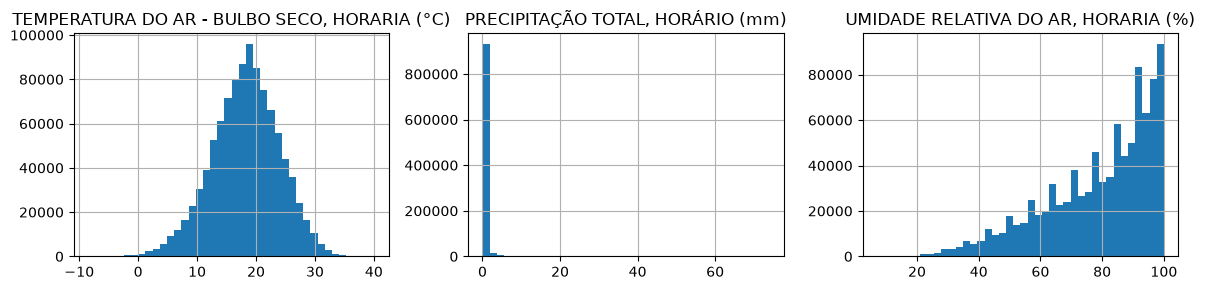

In [48]:
temp_col = "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)"
chuva_col = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"
umid_col = "UMIDADE RELATIVA DO AR, HORARIA (%)"

df_inmet[[temp_col, chuva_col, umid_col]].hist(bins=40, figsize=(12, 3), layout=(1, 3))
plt.tight_layout()
plt.show()

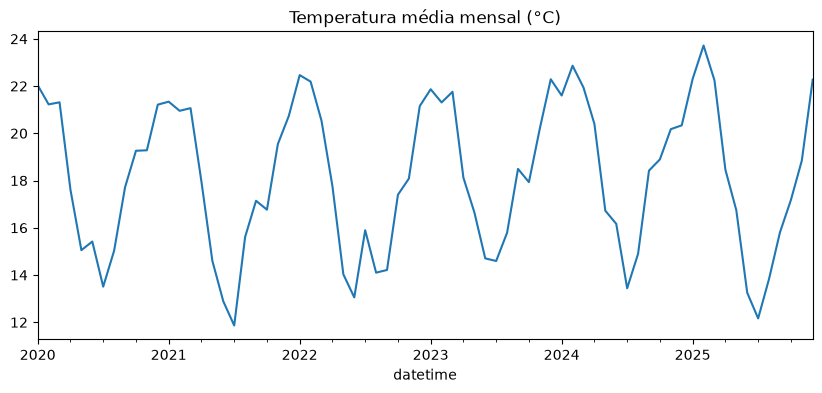

In [49]:
# temperatura média mensal
df_inmet.set_index("datetime")[temp_col].resample("ME").mean().plot(title="Temperatura média mensal (°C)")
plt.show()

## EDA - S2ID

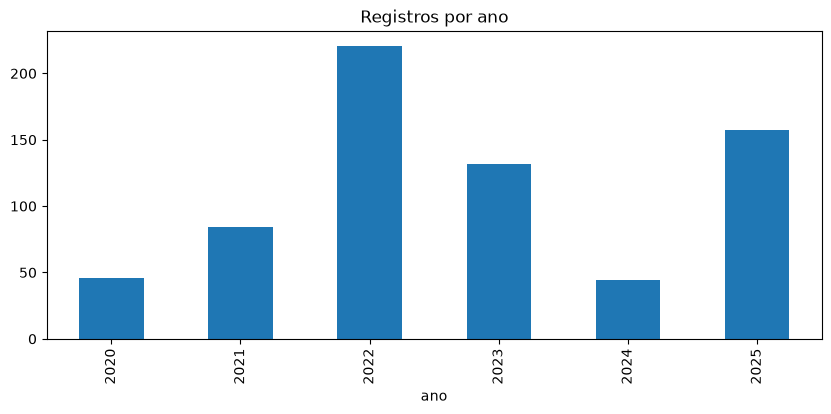

In [50]:
df_s2id["ano"].value_counts().sort_index().plot(kind="bar", title="Registros por ano")
plt.show()

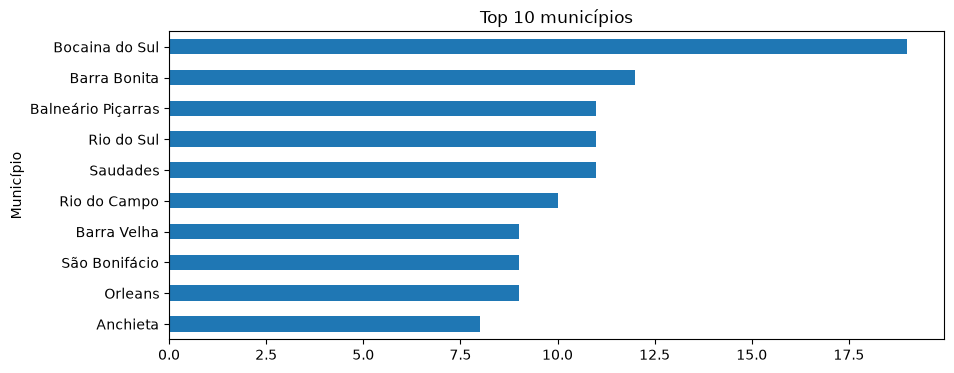

In [51]:
df_s2id["Município"].value_counts().head(10).sort_values().plot(kind="barh", title="Top 10 municípios")
plt.show()

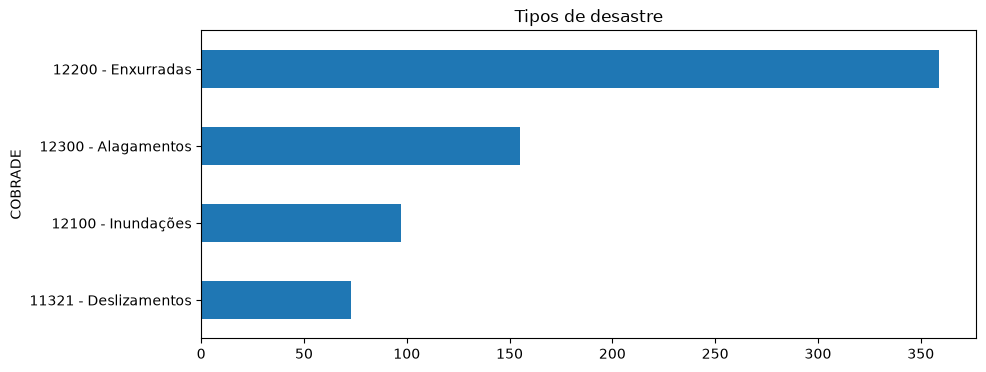

In [52]:
df_s2id["COBRADE"].value_counts().sort_values().plot(kind="barh", title="Tipos de desastre")
plt.show()